This notebook is for training and testing the model

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
)

In [2]:
df = pd.read_csv("processed_datasets/pricing_training_table.csv")

target = "revenue"

# Nur Features nehmen, die numerisch oder kategorial sind
drop_cols = [
    target,
    "load_type",
    "origin_city",
    "destination_city",
    "lane",
    "revenue_per_mile",
    "revenue_per_hour",
    "base_rate_per_mile",
    "fuel_surcharge_rate"
]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df[target].copy()

# datetime-Spalten raus
for c in X.columns:
    if str(X[c].dtype).startswith("datetime"):
        X = X.drop(columns=[c])

# categorical -> category codes
for c in X.columns:
    if X[c].dtype == "string" or X[c].dtype == "object":
        X[c] = X[c].astype("category")

cat_cols = X.select_dtypes(include=["category"]).columns.tolist()
for c in cat_cols:
    X[c] = X[c].cat.codes.replace(-1, np.nan)

# simple fillna
for c in X.columns:
    if X[c].dtype.kind in "biufc":
        X[c] = X[c].fillna(X[c].median())
    else:
        X[c] = X[c].fillna("missing")

In [3]:




X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 242.5257621749594
RMSE: 115954.33104619702


R2 Score: 0.9671
MAPE: 0.0788
Median Absolute Error: 166.7329


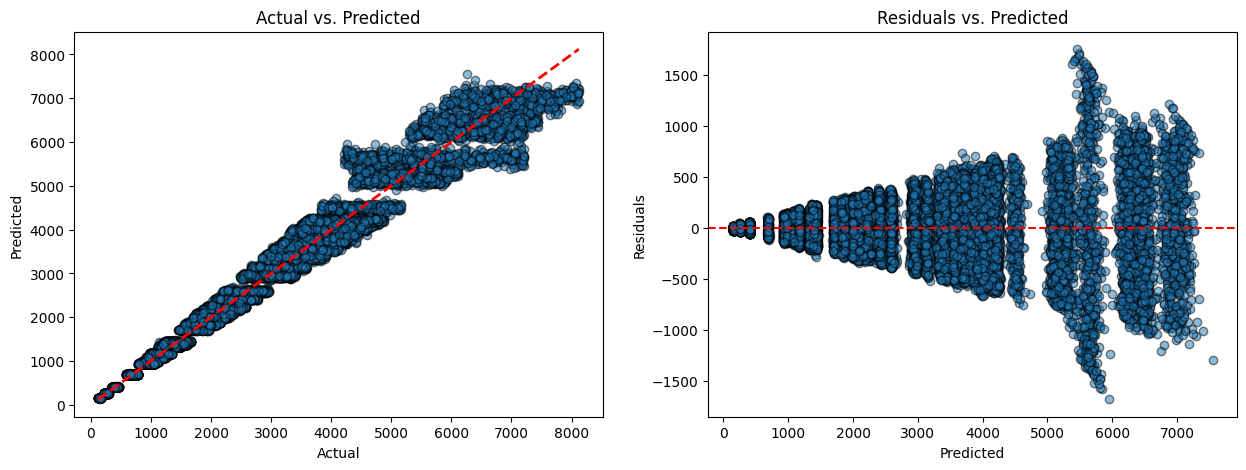

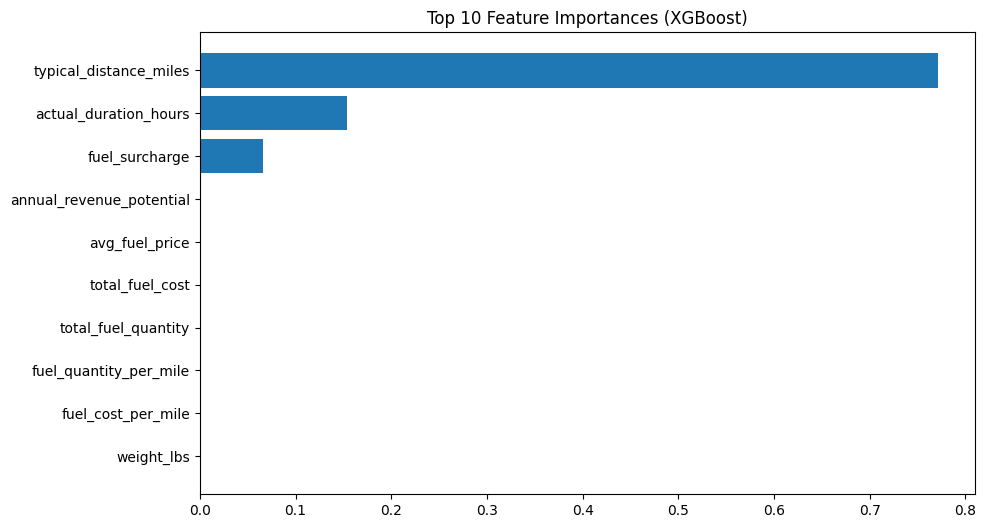

In [4]:
# 1. Calculate Additional Metrics
r2 = r2_score(y_test, pred)
mape = mean_absolute_percentage_error(y_test, pred)
medae = median_absolute_error(y_test, pred)

print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Median Absolute Error: {medae:.4f}")

# 2. Visualizing Performance
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Actual vs Predicted
ax[0].scatter(y_test, pred, alpha=0.5, edgecolors="k")
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
ax[0].set_title("Actual vs. Predicted")
ax[0].set_xlabel("Actual")
ax[0].set_ylabel("Predicted")

# Residual Plot
residuals = y_test - pred
ax[1].scatter(pred, residuals, alpha=0.5, edgecolors="k")
ax[1].axhline(0, color="r", linestyle="--")
ax[1].set_title("Residuals vs. Predicted")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Residuals")

plt.show()

# 3. Feature Importance
plt.figure(figsize=(10, 6))
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10 features
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()